# Tree-Based Regression

## Notebook Objective

This notebook compares an unrestricted Decision Tree Regressor with a controlled Decision Tree Regressor for monthly cost prediction.

The goal is to test whether a nonlinear tree-based model can capture cost patterns that linear regression may miss.

This notebook focuses on overfitting, train-vs-test performance, residual behavior, and tree-based feature importance.

## 1. Imports

In [1]:
import pandas as pd # Used for Loading and working with tabular data
import numpy as np # Used for numerical calculations

import matplotlib.pyplot as plt # Used for visualization

from sklearn.model_selection import train_test_split # Used to split data into train/test sets
from sklearn.compose import ColumnTransformer # Used to apply preprocessing to selected column types
from sklearn.preprocessing import OneHotEncoder # Used to encode categorical variables
from sklearn.pipeline import Pipeline # Used to combine preprocessing and model steps

from sklearn.tree import DecisionTreeRegressor, plot_tree # Main tree regression model and tree visualization 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression evaluation metrics 





## 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the feature-engineered dataset

df.head() # Preview the first few rows


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

In [3]:
target = "monthly_cost" # Define the regression target 

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns = drop_cols) # Create feature matrix without leakage columns
y = df[target] # Create target vector

## Feature Selection Logic

This notebook uses the same cleaned feature set as the prior cost prediction notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost` and would create target leakage.

Grouped variables such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included.

This keeps the tree-based model comparison consistent with the earlier regression notebooks.

## 4. Identify Categorical and Numeric Columns

In [4]:
categorical_cols = X.select_dtypes(
    include = ["object", "string", "category", "bool"]
).columns.tolist() # Detect categorical columns safely

numeric_cols = X.select_dtypes(
    include = ["int64", "float64", "int32", "float32"] 
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['gender', 'region', 'plan_type']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


## 5. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Feature matrix
    y, # Target Vector
    test_size = 0.20, # Use 20% of data for testing
    random_state = 42  # Make split reproducible 
)

## Why Use a Decision Tree Regressor?

A Decision Tree Regressor predicts a continuous target by splitting the data into smaller groups based on feature values.

Unlike Linear Regression, a tree can capture nonlinear relationships and interactions without manually creating interaction terms.

However, unrestricted decision trees can easily overfit. They may memorize the training data instead of learning patterns that generalize to new data.

For that reason, this notebook compares an unrestricted tree with a controlled tree.

## 6. Build Baseline Decision Tree Pipeline

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_cols 
        )
    ],
    remainder = "passthrough" # Keep numeric columns unchanged 
)


tree_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Convert categorical variables to numeric format
        (
            "model",
            DecisionTreeRegressor(
                random_state = 42
            )
        )
    ]
)



## 7. Fit the Model

In [7]:
tree_model.fit(X_train, y_train) # Train the decision tree model 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 8. Evaluate Train vs Test Performance

In [8]:
y_train_pred = tree_model.predict(X_train) # Predict on training data
y_test_pred = tree_model.predict(X_test) # Predict on test data

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

metrics_df





,Dataset,MAE,RMSE,R2
0,Train,0.0000,0.000000,1.000000
1,Test,535.9159,870.358145,0.582105


## Unrestricted Tree Performance Interpretation

The unrestricted decision tree achieved perfect training performance, with train MAE of 0, train RMSE of 0, and train R² of 1.0.

This means the tree memorized the training data.

However, test performance was much weaker, with test MAE around `$536`, RMSE around `$870`, and R² around `0.582`.

This large gap between train and test performance is strong evidence of overfitting.

## 9. Controlled Tree With Max Depth

In [9]:
controlled_tree_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        (
                "model",
                DecisionTreeRegressor(
                    max_depth = 5, # Limit tree complexity
                    min_samples_leaf=25, # Require enough members in each final leaf 
                    random_state=42 
                )
        )
    ]
)

controlled_tree_model.fit(X_train, y_train) # Train controlled tree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 10. Compare Unrestricted vs Controlled Tree

In [10]:
models = {
    "Unrestricted Decision Tree": tree_model, 
    "Controlled Decision Tree": controlled_tree_model
}


results = []

for model_name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

comparison_df = pd.DataFrame(results)
comparison_df 



,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Unrestricted Decision Tree,0.000000,535.915900,0.00000,870.358145,1.000000,0.582105
1,Controlled Decision Tree,407.067508,449.412843,592.88049,709.087534,0.778381,0.722623


## Controlled Tree Performance Interpretation

The controlled tree performs worse on the training set than the unrestricted tree, but better on the test set.

This is the expected tradeoff when reducing overfitting.

The controlled tree improved test RMSE from about `$870` to about `$709`, and test R² from about `0.582` to about `0.723`.

This suggests the controlled tree generalizes better than the unrestricted tree, even though it does not memorize the training data.

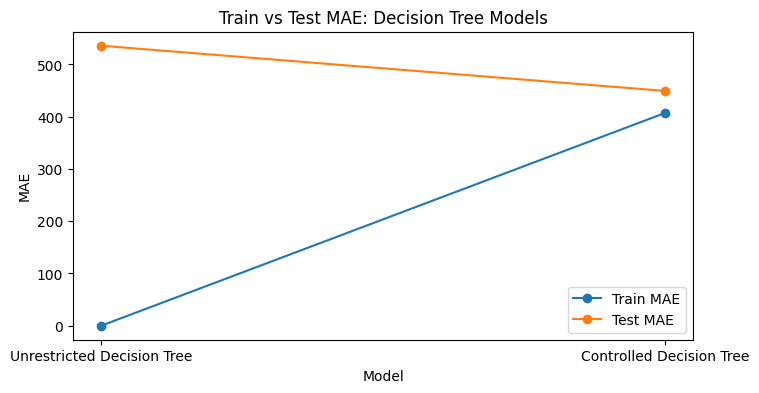

In [11]:
plot_df = comparison_df.set_index("Model")[["Train MAE", "Test MAE"]]

plt.figure(figsize=(8, 4))
plt.plot(plot_df.index, plot_df["Train MAE"], marker="o", label="Train MAE")
plt.plot(plot_df.index, plot_df["Test MAE"], marker="o", label="Test MAE")

plt.title("Train vs Test MAE: Decision Tree Models")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.legend()
plt.show()

## 11. Actual vs Predicted Plot

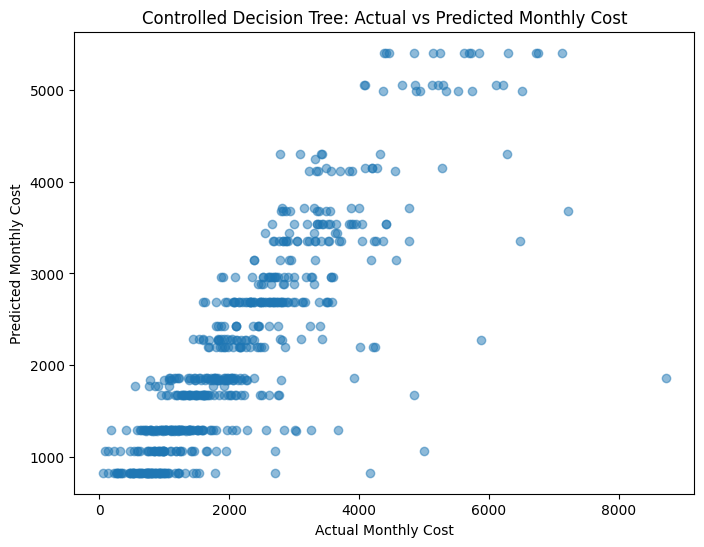

In [12]:
best_tree_pred = controlled_tree_model.predict(X_test) # Use controlled tree for cleaner generalization check 

plt.figure(figsize = (8,6))
plt.scatter(y_test, best_tree_pred, alpha=0.5)
plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Controlled Decision Tree: Actual vs Predicted Monthly Cost")
plt.show()


## 12. Residual Plot

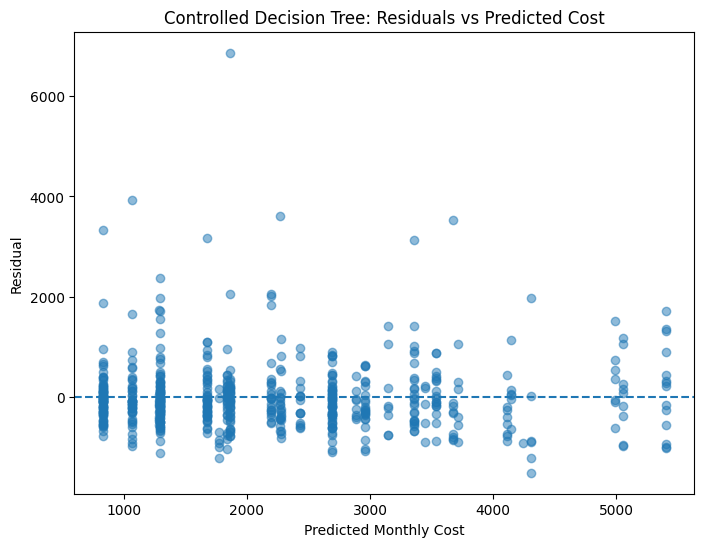

In [13]:
residuals = y_test - best_tree_pred # Calculate prediction errors.

plt.figure(figsize = (8,6))
plt.scatter(best_tree_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Controlled Decision Tree: Residuals vs Predicted Cost")
plt.show()


## Residual Plot Interpretation

The residual plot shows prediction errors from the controlled decision tree.

A residual above zero means the model underpredicted monthly cost. A residual below zero means the model overpredicted monthly cost.

The plot is used to check whether prediction errors are randomly scattered or whether the model systematically misses certain cost ranges.

If residuals widen at higher predicted costs, that suggests the model still struggles with high-cost members.

## 13. Feature Importance

In [14]:
trained_preprocessor = controlled_tree_model.named_steps["preprocessor"] # Access fitted preprocessor
trained_tree = controlled_tree_model.named_steps["model"] # Access fitted tree model

feature_names = trained_preprocessor.get_feature_names_out() # Get encoded feature names 

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_tree.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(15)




,feature,importance
10,remainder__chronic_condition_count,0.599158
15,remainder__ip_admits,0.334908
14,remainder__ed_visits,0.054241
8,remainder__age,0.005219
11,remainder__engagement_score,0.004367
6,cat__plan_type_Medicaid,0.001285
9,remainder__sdoh_risk_score,0.000821
0,cat__gender_Female,0.000000
7,cat__plan_type_Medicare Advantage,0.000000
5,cat__plan_type_DSNP,0.000000


## Feature Importance Interpretation

The controlled decision tree relies most heavily on chronic condition count, inpatient admissions, and ED visits.

This matches the synthetic data-generation logic, where chronic burden and acute utilization are major drivers of monthly cost.

Tree-based feature importance shows which variables were most useful for splitting the data in this fitted model.

Feature importance does not prove causality. A high-importance feature is useful for prediction, not automatically a real-world causal driver.

## 14. Plot Top Feature Importances

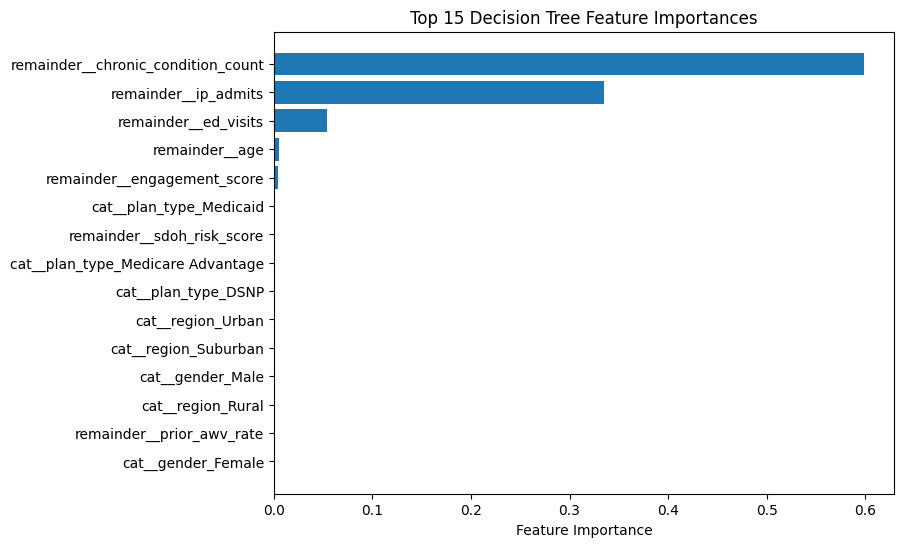

In [15]:
top_features = importance_df.head(15).sort_values(by = "importance") # Select top 15 and reverse for horizontal plot

plt.figure(figsize = (8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Decision Tree Feature Importances")
plt.show()

## 15. Optional Small Tree Visualization

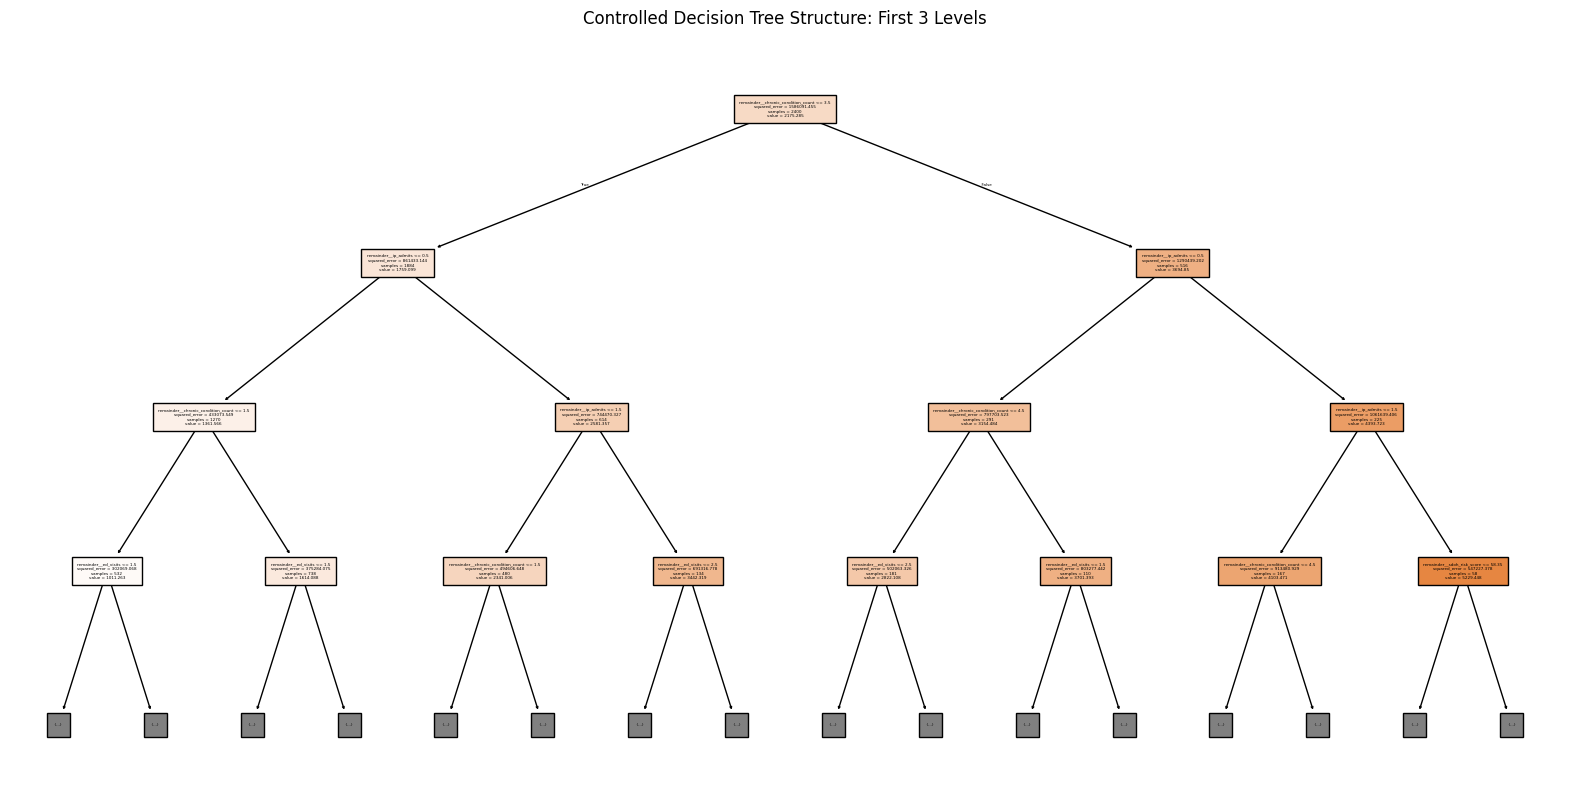

In [16]:
plt.figure(figsize = (20,10))


plot_tree(
    trained_tree,
    feature_names = feature_names,
    filled=True,
    max_depth=3,
    fontsize = 3 
)

plt.title("Controlled Decision Tree Structure: First 3 Levels")
plt.show()

## 16. Findings 

This notebook compared an unrestricted Decision Tree Regressor with a controlled Decision Tree Regressor for monthly cost prediction.

The unrestricted tree perfectly memorized the training data, producing train MAE of 0, train RMSE of 0, and train R² of 1.0. However, its test performance was much weaker, showing clear overfitting.

The controlled tree used `max_depth=5` and `min_samples_leaf=25` to limit tree complexity.

Compared with the unrestricted tree, the controlled tree had worse training performance but better test performance. This indicates better generalization.

The controlled tree achieved test MAE of about `$449`, test RMSE of about `$709`, and test R² of about `0.723`.

The controlled tree still performed worse than the earlier tuned Ridge model, which had test RMSE around `$654` and R² around `0.764`.

Feature importance showed that chronic condition count, inpatient admissions, and ED visits were the most important split variables in the controlled tree.

These results suggest that a simple controlled decision tree can capture some nonlinear cost patterns, but it does not outperform the regularized linear regression model in this synthetic dataset.

A logical next step is to test ensemble tree methods such as Random Forest Regressor and Gradient Boosting Regressor, which often generalize better than a single decision tree.